In [1]:
!pip install -q transformers emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.models as tvm

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

In [3]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BERT_NAME = "vinai/bertweet-base"

MAX_LEN = 128
IMG_SIZE = 224

BATCH_TEXT = 16
BATCH_IMAGE = 16
BATCH_MULTI = 8

ACCUM_STEPS = 2
EPOCHS = 6

LR_BERT = 2e-5
LR_RESNET = 1e-5
LR_HEAD = 2e-4

DROPOUT = 0.2
NUM_CLASSES = 3

LABEL_NAMES = ["negative", "neutral", "positive"]

OUTPUT_DIR = Path("/kaggle/working/twitter2015_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda


In [4]:
DATA_ROOT = Path("/kaggle/input/datasets/dafenqiisgod/twitter15/datasets")

TW15_DIR = DATA_ROOT / "twitter2015"
TW15_IMG = DATA_ROOT / "twitter2015_images"

print("DATA_ROOT:", DATA_ROOT.exists(), DATA_ROOT)
print("TW15_DIR:", TW15_DIR.exists(), TW15_DIR)
print("TW15_IMG:", TW15_IMG.exists(), TW15_IMG)

print("\nFile trong twitter2015:")
for p in TW15_DIR.iterdir():
    print(p.name)

DATA_ROOT: True /kaggle/input/datasets/dafenqiisgod/twitter15/datasets
TW15_DIR: True /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015
TW15_IMG: True /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images

File trong twitter2015:
valid.txt
test.tsv
dev.tsv
train.tsv
test.txt
train.txt


In [5]:
def build_image_map(image_dir):
    image_dir = Path(image_dir)
    image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    image_map = {}

    for p in image_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in image_exts:
            image_map[p.name] = str(p)
            image_map[p.stem] = str(p)

    return image_map

img_map_2015 = build_image_map(TW15_IMG)

print("So key anh Twitter2015:", len(img_map_2015))
print("Vi du 10 key anh dau:")

for k, v in list(img_map_2015.items())[:10]:
    print(k, "=>", v)

So key anh Twitter2015: 16576
Vi du 10 key anh dau:
31973.jpg => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/31973.jpg
31973 => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/31973.jpg
74055.jpg => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/74055.jpg
74055 => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/74055.jpg
1992878.jpg => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/1992878.jpg
1992878 => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/1992878.jpg
335247.jpg => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/335247.jpg
335247 => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/335247.jpg
458861.jpg => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_images/458861.jpg
458861 => /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015_

In [6]:
def load_twitter_absa_split(tsv_path, image_map, split_name):
    cols = ["index", "label", "image_id", "sentence", "target"]

    df = pd.read_csv(
        tsv_path,
        sep="\t",
        names=cols,
        header=0,
        engine="python",
        quoting=3,
        on_bad_lines="skip",
        encoding="utf-8"
    )

    df["image_id"] = df["image_id"].astype(str).str.strip()
    df["image_key"] = df["image_id"].apply(lambda x: Path(x).stem)

    df["sentence"] = df["sentence"].astype(str).fillna("")
    df["target"] = df["target"].astype(str).fillna("")

    df["text"] = df.apply(
        lambda row: row["sentence"].replace("$T$", row["target"]),
        axis=1
    )

    df["text"] = df["text"] + " [SEP] target: " + df["target"]

    df["image_path"] = df["image_id"].map(image_map)

    missing_mask = df["image_path"].isna()
    df.loc[missing_mask, "image_path"] = df.loc[missing_mask, "image_key"].map(image_map)

    df["label"] = pd.to_numeric(df["label"], errors="coerce")

    df = df.dropna(subset=["label", "image_path", "text"])
    df["label"] = df["label"].astype(int)

    df = df[df["label"].isin([0, 1, 2])]
    df = df[df["text"].astype(str).str.len() >= 3]
    df = df[df["image_path"].apply(lambda x: Path(x).exists())]

    df["split"] = split_name

    df = df[["text", "image_path", "label", "split", "image_id", "target"]]
    df = df.reset_index(drop=True)

    print("File:", tsv_path)
    print("Split:", split_name)
    print("So mau:", len(df))
    print(df["label"].value_counts().sort_index())
    display(df.head(5))

    return df

In [7]:
df15_train = load_twitter_absa_split(TW15_DIR / "train.tsv", img_map_2015, "train")
df15_val   = load_twitter_absa_split(TW15_DIR / "dev.tsv",   img_map_2015, "val")
df15_test  = load_twitter_absa_split(TW15_DIR / "test.tsv",  img_map_2015, "test")

df15 = pd.concat([df15_train, df15_val, df15_test], ignore_index=True)

print("Tong mau Twitter2015:", len(df15))

print("\nSo mau theo split:")
print(df15["split"].value_counts())

print("\nSo mau theo label:")
print(df15["label"].value_counts().sort_index())

display(df15.head(10))

File: /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015/train.tsv
Split: train
So mau: 3179
label
0     368
1    1883
2     928
Name: count, dtype: int64


,text,image_path,label,split,image_id,target
0,RT @ ltsChuckBass : Chuck Bass is everything #...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,train,1860693.jpg,Chuck Bass
1,RT @ ltsChuckBass : Chuck Bass is everything #...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,train,1860693.jpg,# MCM
2,Millions For Trayvon September 7 - - - - Shut ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,train,195984.jpg,Millions For Trayvon
3,Millions For Trayvon September 7 - - - - Shut ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,0,train,195984.jpg,New York City
4,Me as John Lennon . [SEP] target: John Lennon,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,train,871618.jpg,John Lennon


File: /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015/dev.tsv
Split: val
So mau: 1122
label
0    149
1    670
2    303
Name: count, dtype: int64


,text,image_path,label,split,image_id,target
0,RT @ FundsOverBuns : Tyga went from pedophile ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,val,975807.jpg,Tyga
1,"Pedro , shellacked , and ready to be sent off ...",/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,val,430626.jpg,Pedro
2,"Pedro , shellacked , and ready to be sent off ...",/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,val,430626.jpg,Cooperstown
3,RT @ Butters 13 : Met Joe Johnson in brickell ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,val,1417047.jpg,Joe Johnson
4,Announcing upgrades to the software that power...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,val,111056.jpg,ECS Appliance


File: /kaggle/input/datasets/dafenqiisgod/twitter15/datasets/twitter2015/test.tsv
Split: test
So mau: 1037
label
0    113
1    607
2    317
Name: count, dtype: int64


,text,image_path,label,split,image_id,target
0,RT @ OU Football : Practice one in the books W...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,74960.jpg,Oklahoma
1,Crazy hair day ! Lydia is a contender . : ) [S...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,test,1739565.jpg,Lydia
2,RT @ HistoryNeedsYou : Mother and child # art ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,664451.jpg,Barbara Hepworth
3,Detailed illustrations of mythical creatures b...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,1997881.jpg,Jessica Fortner
4,RT @ bohemianizm : Art from Rachael Speirs # a...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,1794188.jpg,Rachael Speirs


Tong mau Twitter2015: 5338

So mau theo split:
split
train    3179
val      1122
test     1037
Name: count, dtype: int64

So mau theo label:
label
0     630
1    3160
2    1548
Name: count, dtype: int64


,text,image_path,label,split,image_id,target
0,RT @ ltsChuckBass : Chuck Bass is everything #...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,train,1860693.jpg,Chuck Bass
1,RT @ ltsChuckBass : Chuck Bass is everything #...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,train,1860693.jpg,# MCM
2,Millions For Trayvon September 7 - - - - Shut ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,train,195984.jpg,Millions For Trayvon
3,Millions For Trayvon September 7 - - - - Shut ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,0,train,195984.jpg,New York City
4,Me as John Lennon . [SEP] target: John Lennon,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,train,871618.jpg,John Lennon
5,Former Bridgecorp boss Rod Petricevic will be ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,train,280704.jpg,Bridgecorp
6,Former Bridgecorp boss Rod Petricevic will be ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,0,train,280704.jpg,Rod Petricevic
7,Tried HoloLens for an out of game Halo 5 exper...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,train,638395.jpg,HoloLens
8,Tried HoloLens for an out of game Halo 5 exper...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,train,638395.jpg,# E3
9,RT @ BBC Travel : Chasing light and shadows in...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,train,138186.jpg,# Iran


In [8]:
df_all = df15.copy()

df_train = df_all[df_all["split"] == "train"].reset_index(drop=True)
df_val   = df_all[df_all["split"] == "val"].reset_index(drop=True)
df_test  = df_all[df_all["split"] == "test"].reset_index(drop=True)

print("Train:", df_train.shape)
print("Val:", df_val.shape)
print("Test:", df_test.shape)

print("\nTrain label:")
print(df_train["label"].value_counts().sort_index())

print("\nVal label:")
print(df_val["label"].value_counts().sort_index())

print("\nTest label:")
print(df_test["label"].value_counts().sort_index())

Train: (3179, 6)
Val: (1122, 6)
Test: (1037, 6)

Train label:
label
0     368
1    1883
2     928
Name: count, dtype: int64

Val label:
label
0    149
1    670
2    303
Name: count, dtype: int64

Test label:
label
0    113
1    607
2    317
Name: count, dtype: int64


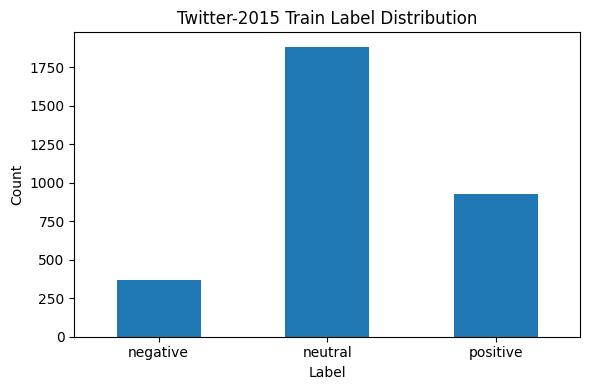

In [9]:
plt.figure(figsize=(6, 4))
df_train["label"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1, 2], LABEL_NAMES, rotation=0)
plt.title("Twitter-2015 Train Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_distribution.png", dpi=200)
plt.show()

In [10]:
tokenizer = AutoTokenizer.from_pretrained(
    BERT_NAME,
    normalization=True,
    use_fast=False
)

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.3),
    T.RandomRotation(5),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
class Twitter2015Dataset(Dataset):
    def __init__(self, df, tokenizer, transform=None, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = str(row["text"])
        image_path = str(row["image_path"])
        label = int(row["label"])

        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        try:
            image = Image.open(image_path).convert("RGB")
        except:
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(0, 0, 0))

        if self.transform:
            image = self.transform(image)

        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }

        return item

In [12]:
train_ds = Twitter2015Dataset(df_train, tokenizer, train_tfms, MAX_LEN)
val_ds   = Twitter2015Dataset(df_val,   tokenizer, valid_tfms, MAX_LEN)
test_ds  = Twitter2015Dataset(df_test,  tokenizer, valid_tfms, MAX_LEN)

train_loader_text = DataLoader(
    train_ds,
    batch_size=BATCH_TEXT,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_text = DataLoader(
    val_ds,
    batch_size=BATCH_TEXT,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_text = DataLoader(
    test_ds,
    batch_size=BATCH_TEXT,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

train_loader_image = DataLoader(
    train_ds,
    batch_size=BATCH_IMAGE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_image = DataLoader(
    val_ds,
    batch_size=BATCH_IMAGE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_image = DataLoader(
    test_ds,
    batch_size=BATCH_IMAGE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

train_loader_multi = DataLoader(
    train_ds,
    batch_size=BATCH_MULTI,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_multi = DataLoader(
    val_ds,
    batch_size=BATCH_MULTI,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_multi = DataLoader(
    test_ds,
    batch_size=BATCH_MULTI,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [13]:
classes = np.array([0, 1, 2])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label"].values
)

weights = np.sqrt(weights)
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float).to(DEVICE)

print("Class weights:", CLASS_WEIGHTS)

Class weights: tensor([1.6969, 0.7502, 1.0686], device='cuda:0')


In [14]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }


def show_report(y_true, y_pred, title="Report"):
    print("=" * 60)
    print(title)
    print("=" * 60)
    print(classification_report(
        y_true,
        y_pred,
        target_names=LABEL_NAMES,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:")
    print(cm)

In [15]:
def move_batch_to_device(batch, device):
    return {
        k: v.to(device)
        for k, v in batch.items()
    }


def train_one_epoch(model, loader, optimizer, scheduler, criterion, use_text=True, use_image=True):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = move_batch_to_device(batch, DEVICE)

        outputs = model(batch)
        loss = criterion(outputs, batch["label"])
        loss = loss / ACCUM_STEPS

        loss.backward()

        if (step + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUM_STEPS

        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        labels = batch["label"].detach().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)

        outputs = model(batch)
        loss = criterion(outputs, batch["label"])

        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        labels = batch["label"].detach().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)
        all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(model, train_loader, val_loader, model_name, epochs=EPOCHS):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS,
        label_smoothing=0.03
    )

    no_decay = ["bias", "LayerNorm.weight"]

    optimizer_grouped_parameters = []

    bert_params = []
    other_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if "bert" in name:
            bert_params.append((name, param))
        else:
            other_params.append((name, param))

    optimizer_grouped_parameters += [
        {
            "params": [p for n, p in bert_params if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
            "lr": LR_BERT
        },
        {
            "params": [p for n, p in bert_params if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": LR_BERT
        },
        {
            "params": [p for n, p in other_params],
            "weight_decay": 1e-4,
            "lr": LR_HEAD
        }
    ]

    optimizer = AdamW(optimizer_grouped_parameters)

    total_steps = len(train_loader) * epochs // ACCUM_STEPS
    warmup_steps = int(total_steps * 0.1)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    best_f1 = -1
    best_path = OUTPUT_DIR / f"{model_name}.pth"
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            criterion
        )

        val_loss, val_metrics, _, _, _ = evaluate_model(
            model,
            val_loader,
            criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }

        history.append(row)

        print(f"\n[{model_name}] Epoch {epoch}/{epochs}")
        print(f"Train loss: {train_loss:.4f} | Acc: {train_metrics['accuracy']:.4f} | F1 macro: {train_metrics['f1_macro']:.4f}")
        print(f"Val   loss: {val_loss:.4f} | Acc: {val_metrics['accuracy']:.4f} | F1 macro: {val_metrics['f1_macro']:.4f}")

        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    return model, hist_df

In [16]:
class TextOnlyBERTweet(nn.Module):
    def __init__(self, bert_name=BERT_NAME, num_classes=3, dropout=0.2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(bert_name)
        hidden = self.bert.config.hidden_size

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, batch):
        out = self.bert(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        cls = out.last_hidden_state[:, 0, :]
        logits = self.head(cls)

        return logits

In [17]:
gc.collect()
torch.cuda.empty_cache()

model_text = TextOnlyBERTweet()

model_text, hist_text = train_model(
    model_text,
    train_loader_text,
    val_loader_text,
    "bertweet_text_only",
    EPOCHS
)

criterion_eval = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS,
    label_smoothing=0.03
)

test_loss_text, test_metrics_text, y_true_text, y_pred_text, prob_text = evaluate_model(
    model_text,
    test_loader_text,
    criterion_eval
)

print("\nTEST BERTweet Text-Only")
print(test_metrics_text)

show_report(y_true_text, y_pred_text, "BERTweet Text-Only Test Report")

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]


[bertweet_text_only] Epoch 1/6
Train loss: 0.9971 | Acc: 0.5857 | F1 macro: 0.4289
Val   loss: 0.8507 | Acc: 0.5909 | F1 macro: 0.5663
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_text_only.pth

[bertweet_text_only] Epoch 2/6
Train loss: 0.7436 | Acc: 0.6936 | F1 macro: 0.6633
Val   loss: 0.7717 | Acc: 0.7032 | F1 macro: 0.6601
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_text_only.pth

[bertweet_text_only] Epoch 3/6
Train loss: 0.5790 | Acc: 0.7858 | F1 macro: 0.7599
Val   loss: 0.7925 | Acc: 0.6872 | F1 macro: 0.6485

[bertweet_text_only] Epoch 4/6
Train loss: 0.4814 | Acc: 0.8405 | F1 macro: 0.8192
Val   loss: 0.7818 | Acc: 0.7112 | F1 macro: 0.6717
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_text_only.pth

[bertweet_text_only] Epoch 5/6
Train loss: 0.3977 | Acc: 0.8890 | F1 macro: 0.8690
Val   loss: 0.8262 | Acc: 0.7246 | F1 macro: 0.6746
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_text_only.pth

[bertweet_t

In [18]:
class ImageOnlyResNet50(nn.Module):
    def __init__(self, num_classes=3, dropout=0.2):
        super().__init__()

        weights = tvm.ResNet50_Weights.IMAGENET1K_V2
        backbone = tvm.resnet50(weights=weights)

        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, batch):
        feat = self.backbone(batch["image"])
        logits = self.head(feat)
        return logits

In [19]:
gc.collect()
torch.cuda.empty_cache()

model_image = ImageOnlyResNet50()

model_image, hist_image = train_model(
    model_image,
    train_loader_image,
    val_loader_image,
    "resnet50_image_only",
    EPOCHS
)

test_loss_image, test_metrics_image, y_true_image, y_pred_image, prob_image = evaluate_model(
    model_image,
    test_loader_image,
    criterion_eval
)

print("\nTEST ResNet50 Image-Only")
print(test_metrics_image)

show_report(y_true_image, y_pred_image, "ResNet50 Image-Only Test Report")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]



[resnet50_image_only] Epoch 1/6
Train loss: 1.0530 | Acc: 0.5599 | F1 macro: 0.3477
Val   loss: 1.0394 | Acc: 0.5820 | F1 macro: 0.3205
Saved best model: /kaggle/working/twitter2015_outputs/resnet50_image_only.pth

[resnet50_image_only] Epoch 2/6
Train loss: 0.9446 | Acc: 0.6197 | F1 macro: 0.4874
Val   loss: 1.0778 | Acc: 0.5267 | F1 macro: 0.4256
Saved best model: /kaggle/working/twitter2015_outputs/resnet50_image_only.pth

[resnet50_image_only] Epoch 3/6
Train loss: 0.7607 | Acc: 0.7122 | F1 macro: 0.6574
Val   loss: 1.1584 | Acc: 0.4697 | F1 macro: 0.3928

[resnet50_image_only] Epoch 4/6
Train loss: 0.6038 | Acc: 0.7870 | F1 macro: 0.7571
Val   loss: 1.2433 | Acc: 0.4670 | F1 macro: 0.3980

[resnet50_image_only] Epoch 5/6
Train loss: 0.5092 | Acc: 0.8399 | F1 macro: 0.8196
Val   loss: 1.2921 | Acc: 0.5062 | F1 macro: 0.4137

[resnet50_image_only] Epoch 6/6
Train loss: 0.4384 | Acc: 0.8588 | F1 macro: 0.8394
Val   loss: 1.3353 | Acc: 0.5027 | F1 macro: 0.4095

TEST ResNet50 Image-O

In [20]:
class LateFusionBERTResNet(nn.Module):
    def __init__(self, bert_name=BERT_NAME, num_classes=3, dropout=0.2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(bert_name)
        bert_hidden = self.bert.config.hidden_size

        self.text_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(bert_hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

        weights = tvm.ResNet50_Weights.IMAGENET1K_V2
        resnet = tvm.resnet50(weights=weights)

        img_dim = resnet.fc.in_features
        resnet.fc = nn.Identity()

        self.resnet = resnet

        self.image_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(img_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

        self.fusion_w = nn.Parameter(torch.tensor([0.85, 0.15], dtype=torch.float))

    def forward(self, batch):
        text_out = self.bert(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        text_cls = text_out.last_hidden_state[:, 0, :]
        text_logits = self.text_head(text_cls)

        img_feat = self.resnet(batch["image"])
        img_logits = self.image_head(img_feat)

        w = torch.softmax(self.fusion_w, dim=0)

        logits = w[0] * text_logits + w[1] * img_logits

        return logits

In [21]:
gc.collect()
torch.cuda.empty_cache()

model_late = LateFusionBERTResNet()

model_late, hist_late = train_model(
    model_late,
    train_loader_multi,
    val_loader_multi,
    "late_fusion_bertweet_resnet50",
    EPOCHS
)

test_loss_late, test_metrics_late, y_true_late, y_pred_late, prob_late = evaluate_model(
    model_late,
    test_loader_multi,
    criterion_eval
)

print("\nTEST Late Fusion")
print(test_metrics_late)

show_report(y_true_late, y_pred_late, "Late Fusion Test Report")

print("Learned fusion weight:", torch.softmax(model_late.fusion_w.detach().cpu(), dim=0))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[late_fusion_bertweet_resnet50] Epoch 1/6
Train loss: 0.9968 | Acc: 0.5706 | F1 macro: 0.3999
Val   loss: 0.8174 | Acc: 0.6453 | F1 macro: 0.6135
Saved best model: /kaggle/working/twitter2015_outputs/late_fusion_bertweet_resnet50.pth

[late_fusion_bertweet_resnet50] Epoch 2/6
Train loss: 0.6991 | Acc: 0.7307 | F1 macro: 0.6955
Val   loss: 0.7324 | Acc: 0.7112 | F1 macro: 0.6761
Saved best model: /kaggle/working/twitter2015_outputs/late_fusion_bertweet_resnet50.pth

[late_fusion_bertweet_resnet50] Epoch 3/6
Train loss: 0.5235 | Acc: 0.8248 | F1 macro: 0.7995
Val   loss: 0.7535 | Acc: 0.7317 | F1 macro: 0.6900
Saved best model: /kaggle/working/twitter2015_outputs/late_fusion_bertweet_resnet50.pth

[late_fusion_bertweet_resnet50] Epoch 4/6
Train loss: 0.3933 | Acc: 0.8921 | F1 macro: 0.8726
Val   loss: 0.8406 | Acc: 0.7335 | F1 macro: 0.6845

[late_fusion_bertweet_resnet50] Epoch 5/6
Train loss: 0.3020 | Acc: 0.9346 | F1 macro: 0.9194
Val   loss: 0.8906 | Acc: 0.7317 | F1 macro: 0.6910
S

In [22]:
class EarlyFusionBERTResNet(nn.Module):
    def __init__(self, bert_name=BERT_NAME, num_classes=3, dropout=0.15):
        super().__init__()

        self.bert = AutoModel.from_pretrained(bert_name)
        bert_hidden = self.bert.config.hidden_size

        weights = tvm.ResNet50_Weights.IMAGENET1K_V2
        resnet = tvm.resnet50(weights=weights)

        img_dim = resnet.fc.in_features
        resnet.fc = nn.Identity()

        self.resnet = resnet

        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, bert_hidden),
            nn.LayerNorm(bert_hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.fusion = nn.Sequential(
            nn.Linear(bert_hidden * 2, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes)
        )

    def forward(self, batch):
        text_out = self.bert(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        text_cls = text_out.last_hidden_state[:, 0, :]

        img_feat = self.resnet(batch["image"])
        img_feat = self.img_proj(img_feat)

        fused = torch.cat([text_cls, img_feat], dim=1)

        logits = self.fusion(fused)

        return logits

In [23]:
def train_early_fusion_stable(model, train_loader, val_loader, model_name, epochs=6):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS,
        label_smoothing=0.02
    )

    optimizer = AdamW([
        {
            "params": model.bert.parameters(),
            "lr": 2e-5,
            "weight_decay": 0.01
        },
        {
            "params": model.resnet.parameters(),
            "lr": 3e-6,
            "weight_decay": 1e-4
        },
        {
            "params": list(model.img_proj.parameters()) + list(model.fusion.parameters()),
            "lr": 2e-4,
            "weight_decay": 1e-4
        }
    ])

    total_steps = len(train_loader) * epochs // ACCUM_STEPS
    warmup_steps = int(total_steps * 0.1)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    best_score = -1
    best_path = OUTPUT_DIR / f"{model_name}.pth"
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            criterion
        )

        val_loss, val_metrics, _, _, _ = evaluate_model(
            model,
            val_loader,
            criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }

        history.append(row)

        print(f"\n[{model_name}] Epoch {epoch}/{epochs}")
        print(f"Train Acc: {train_metrics['accuracy']:.4f} | F1 macro: {train_metrics['f1_macro']:.4f}")
        print(f"Val   Acc: {val_metrics['accuracy']:.4f} | F1 macro: {val_metrics['f1_macro']:.4f}")

        # Nếu mục tiêu của bạn là accuracy cao hơn thì lưu theo val accuracy
        if val_metrics["accuracy"] > best_score:
            best_score = val_metrics["accuracy"]
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    return model, hist_df

In [24]:
def train_early_fusion_stable(model, train_loader, val_loader, model_name, epochs=6):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS,
        label_smoothing=0.02
    )

    optimizer = AdamW([
        {
            "params": model.bert.parameters(),
            "lr": 2e-5,
            "weight_decay": 0.01
        },
        {
            "params": model.resnet.parameters(),
            "lr": 3e-6,
            "weight_decay": 1e-4
        },
        {
            "params": list(model.img_proj.parameters()) + list(model.fusion.parameters()),
            "lr": 2e-4,
            "weight_decay": 1e-4
        }
    ])

    total_steps = len(train_loader) * epochs // ACCUM_STEPS
    warmup_steps = int(total_steps * 0.1)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    best_score = -1
    best_path = OUTPUT_DIR / f"{model_name}.pth"
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            criterion
        )

        val_loss, val_metrics, _, _, _ = evaluate_model(
            model,
            val_loader,
            criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }

        history.append(row)

        print(f"\n[{model_name}] Epoch {epoch}/{epochs}")
        print(f"Train Acc: {train_metrics['accuracy']:.4f} | F1 macro: {train_metrics['f1_macro']:.4f}")
        print(f"Val   Acc: {val_metrics['accuracy']:.4f} | F1 macro: {val_metrics['f1_macro']:.4f}")

        # Nếu mục tiêu của bạn là accuracy cao hơn thì lưu theo val accuracy
        if val_metrics["accuracy"] > best_score:
            best_score = val_metrics["accuracy"]
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    return model, hist_df

In [25]:
gc.collect()
torch.cuda.empty_cache()

model_early = EarlyFusionBERTResNet(dropout=0.15)

try:
    model_early.bert.load_state_dict(model_text.bert.state_dict())
    print("Loaded BERT weights from Text-Only model")
except Exception as e:
    print("Cannot load Text-Only BERT weights:", e)

try:
    model_early.resnet.load_state_dict(model_image.backbone.state_dict())
    print("Loaded ResNet weights from Image-Only model")
except Exception as e:
    print("Cannot load Image-Only ResNet weights:", e)

model_early, hist_early = train_early_fusion_stable(
    model_early,
    train_loader_multi,
    val_loader_multi,
    "early_fusion_stable_bertweet_resnet50",
    epochs=6
)

test_loss_early, test_metrics_early, y_true_early, y_pred_early, prob_early = evaluate_model(
    model_early,
    test_loader_multi,
    criterion_eval
)

print("\nTEST Stable Early Fusion")
print(test_metrics_early)

show_report(y_true_early, y_pred_early, "Stable Early Fusion Test Report")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded BERT weights from Text-Only model
Loaded ResNet weights from Image-Only model

[early_fusion_stable_bertweet_resnet50] Epoch 1/6
Train Acc: 0.8333 | F1 macro: 0.8016
Val   Acc: 0.7255 | F1 macro: 0.6664
Saved best model: /kaggle/working/twitter2015_outputs/early_fusion_stable_bertweet_resnet50.pth

[early_fusion_stable_bertweet_resnet50] Epoch 2/6
Train Acc: 0.8930 | F1 macro: 0.8734
Val   Acc: 0.7121 | F1 macro: 0.6739

[early_fusion_stable_bertweet_resnet50] Epoch 3/6
Train Acc: 0.9295 | F1 macro: 0.9142
Val   Acc: 0.7086 | F1 macro: 0.6508

[early_fusion_stable_bertweet_resnet50] Epoch 4/6
Train Acc: 0.9553 | F1 macro: 0.9446
Val   Acc: 0.7398 | F1 macro: 0.6674
Saved best model: /kaggle/working/twitter2015_outputs/early_fusion_stable_bertweet_resnet50.pth

[early_fusion_stable_bertweet_resnet50] Epoch 5/6
Train Acc: 0.9742 | F1 macro: 0.9659
Val   Acc: 0.7353 | F1 macro: 0.6874

[early_fusion_stable_bertweet_resnet50] Epoch 6/6
Train Acc: 0.9824 | F1 macro: 0.9764
Val   Acc:

In [26]:
results = [
    {
        "model": "BERTweet Text-Only",
        "accuracy": test_metrics_text["accuracy"],
        "precision_macro": test_metrics_text["precision_macro"],
        "recall_macro": test_metrics_text["recall_macro"],
        "f1_macro": test_metrics_text["f1_macro"],
        "f1_weighted": test_metrics_text["f1_weighted"]
    },
    {
        "model": "ResNet50 Image-Only",
        "accuracy": test_metrics_image["accuracy"],
        "precision_macro": test_metrics_image["precision_macro"],
        "recall_macro": test_metrics_image["recall_macro"],
        "f1_macro": test_metrics_image["f1_macro"],
        "f1_weighted": test_metrics_image["f1_weighted"]
    },
    {
        "model": "Late Fusion",
        "accuracy": test_metrics_late["accuracy"],
        "precision_macro": test_metrics_late["precision_macro"],
        "recall_macro": test_metrics_late["recall_macro"],
        "f1_macro": test_metrics_late["f1_macro"],
        "f1_weighted": test_metrics_late["f1_weighted"]
    },
    {
        "model": "Early Fusion",
        "accuracy": test_metrics_early["accuracy"],
        "precision_macro": test_metrics_early["precision_macro"],
        "recall_macro": test_metrics_early["recall_macro"],
        "f1_macro": test_metrics_early["f1_macro"],
        "f1_weighted": test_metrics_early["f1_weighted"]
    }
]

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)

display(results_df)

results_df.to_csv(OUTPUT_DIR / "twitter2015_final_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "twitter2015_final_results.csv")

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,BERTweet Text-Only,0.769527,0.730316,0.741805,0.735451,0.769602
1,Late Fusion,0.766635,0.715302,0.747301,0.729300,0.768890
2,Early Fusion,0.765670,0.744282,0.681266,0.706308,0.760350
3,ResNet50 Image-Only,0.542912,0.425846,0.404684,0.407416,0.528703


Saved: /kaggle/working/twitter2015_outputs/twitter2015_final_results.csv


In [27]:
pred_df = df_test.copy()

pred_df["true_label"] = y_true_text

pred_df["pred_text"] = y_pred_text
pred_df["pred_image"] = y_pred_image
pred_df["pred_late"] = y_pred_late
pred_df["pred_early"] = y_pred_early

pred_df["true_name"] = pred_df["true_label"].map(lambda x: LABEL_NAMES[int(x)])
pred_df["pred_text_name"] = pred_df["pred_text"].map(lambda x: LABEL_NAMES[int(x)])
pred_df["pred_image_name"] = pred_df["pred_image"].map(lambda x: LABEL_NAMES[int(x)])
pred_df["pred_late_name"] = pred_df["pred_late"].map(lambda x: LABEL_NAMES[int(x)])
pred_df["pred_early_name"] = pred_df["pred_early"].map(lambda x: LABEL_NAMES[int(x)])

pred_df.to_csv(OUTPUT_DIR / "twitter2015_predictions.csv", index=False)

display(pred_df.head(20))

print("Saved:", OUTPUT_DIR / "twitter2015_predictions.csv")

,text,image_path,label,split,image_id,target,true_label,pred_text,pred_image,pred_late,pred_early,true_name,pred_text_name,pred_image_name,pred_late_name,pred_early_name
0,RT @ OU Football : Practice one in the books W...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,74960.jpg,Oklahoma,1,1,2,1,1,neutral,neutral,positive,neutral,neutral
1,Crazy hair day ! Lydia is a contender . : ) [S...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,test,1739565.jpg,Lydia,2,2,2,2,2,positive,positive,positive,positive,positive
2,RT @ HistoryNeedsYou : Mother and child # art ...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,664451.jpg,Barbara Hepworth,1,1,1,1,1,neutral,neutral,neutral,neutral,neutral
3,Detailed illustrations of mythical creatures b...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,1997881.jpg,Jessica Fortner,1,1,1,1,1,neutral,neutral,neutral,neutral,neutral
4,RT @ bohemianizm : Art from Rachael Speirs # a...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,1794188.jpg,Rachael Speirs,1,1,1,2,1,neutral,neutral,neutral,positive,neutral
5,RT @ wemssecnirp : Now I really am like Cleopa...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,test,758256.jpg,Cleopatra,2,2,2,2,2,positive,positive,positive,positive,positive
6,"RT @ Grady : Where you at , Nene ? ? ? [SEP] t...",/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,12935.jpg,Nene,1,2,1,1,1,neutral,positive,neutral,neutral,neutral
7,RT @ OfficialFOXES : Departing from Heathrow t...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,1294593.jpg,Heathrow,1,1,1,1,1,neutral,neutral,neutral,neutral,neutral
8,RT @ OfficialFOXES : Departing from Heathrow t...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,1,test,1294593.jpg,Bangkok,1,1,1,1,1,neutral,neutral,neutral,neutral,neutral
9,RT @ engadget : White House Demo Day focuses o...,/kaggle/input/datasets/dafenqiisgod/twitter15/...,2,test,14581.jpg,White House Demo Day,2,1,1,1,1,positive,neutral,neutral,neutral,neutral


Saved: /kaggle/working/twitter2015_outputs/twitter2015_predictions.csv


Best model: BERTweet Text-Only


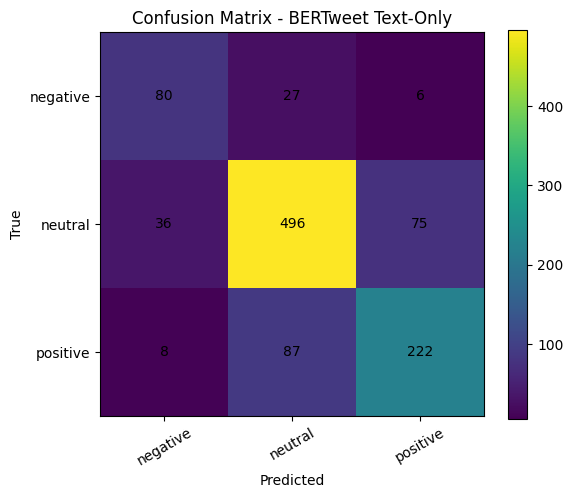

In [28]:
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)

if best_model_name == "BERTweet Text-Only":
    best_true = y_true_text
    best_pred = y_pred_text
elif best_model_name == "ResNet50 Image-Only":
    best_true = y_true_image
    best_pred = y_pred_image
elif best_model_name == "Late Fusion":
    best_true = y_true_late
    best_pred = y_pred_late
else:
    best_true = y_true_early
    best_pred = y_pred_early

cm = confusion_matrix(best_true, best_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()

tick_marks = np.arange(len(LABEL_NAMES))
plt.xticks(tick_marks, LABEL_NAMES, rotation=30)
plt.yticks(tick_marks, LABEL_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_confusion_matrix.png", dpi=200)
plt.show()

In [29]:
print("Output files:")

for p in OUTPUT_DIR.iterdir():
    print(p)

Output files:
/kaggle/working/twitter2015_outputs/late_fusion_bertweet_resnet50.pth
/kaggle/working/twitter2015_outputs/late_fusion_bertweet_resnet50_history.csv
/kaggle/working/twitter2015_outputs/label_distribution.png
/kaggle/working/twitter2015_outputs/resnet50_image_only_history.csv
/kaggle/working/twitter2015_outputs/early_fusion_stable_bertweet_resnet50_history.csv
/kaggle/working/twitter2015_outputs/early_fusion_stable_bertweet_resnet50.pth
/kaggle/working/twitter2015_outputs/bertweet_text_only_history.csv
/kaggle/working/twitter2015_outputs/twitter2015_final_results.csv
/kaggle/working/twitter2015_outputs/bertweet_text_only.pth
/kaggle/working/twitter2015_outputs/resnet50_image_only.pth
/kaggle/working/twitter2015_outputs/best_confusion_matrix.png
/kaggle/working/twitter2015_outputs/twitter2015_predictions.csv


In [30]:
from transformers import CLIPProcessor, CLIPModel

In [31]:
CLIP_NAME = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(CLIP_NAME)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [32]:
class Twitter2015CLIPDataset(Dataset):
    def __init__(self, df, tokenizer, clip_processor, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.clip_processor = clip_processor
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = str(row["text"])
        image_path = str(row["image_path"])
        label = int(row["label"])

        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        try:
            image = Image.open(image_path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224), color=(0, 0, 0))

        clip_inputs = self.clip_processor(
            images=image,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "pixel_values": clip_inputs["pixel_values"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [33]:
clip_train_ds = Twitter2015CLIPDataset(df_train, tokenizer, clip_processor, MAX_LEN)
clip_val_ds   = Twitter2015CLIPDataset(df_val, tokenizer, clip_processor, MAX_LEN)
clip_test_ds  = Twitter2015CLIPDataset(df_test, tokenizer, clip_processor, MAX_LEN)

train_loader_clip = DataLoader(
    clip_train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_clip = DataLoader(
    clip_val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_clip = DataLoader(
    clip_test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [34]:
class BERTweetCLIPFusion(nn.Module):
    def __init__(self, bert_name=BERT_NAME, clip_name="openai/clip-vit-base-patch32", num_classes=3, dropout=0.15):
        super().__init__()

        self.bert = AutoModel.from_pretrained(bert_name)
        self.clip = CLIPModel.from_pretrained(clip_name)

        bert_dim = self.bert.config.hidden_size
        clip_dim = self.clip.config.vision_config.hidden_size  # 768 voi clip-vit-base-patch32

        # Khong dung text encoder cua CLIP
        for p in self.clip.text_model.parameters():
            p.requires_grad = False

        self.img_proj = nn.Sequential(
            nn.Linear(clip_dim, bert_dim),
            nn.LayerNorm(bert_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.fusion = nn.Sequential(
            nn.Linear(bert_dim * 2, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes)
        )

    def forward(self, batch):
        text_out = self.bert(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        text_feat = text_out.last_hidden_state[:, 0, :]

        image_outputs = self.clip.vision_model(
            pixel_values=batch["pixel_values"]
        )

        image_feat = image_outputs.pooler_output

        image_feat = self.img_proj(image_feat)

        fused = torch.cat([text_feat, image_feat], dim=1)

        logits = self.fusion(fused)

        return logits

In [35]:
def move_batch_to_device(batch, device):
    return {
        k: v.to(device)
        for k, v in batch.items()
    }

In [36]:
def train_clip_fusion(model, train_loader, val_loader, model_name, epochs=6):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS,
        label_smoothing=0.02
    )

    optimizer = AdamW([
        {
            "params": model.bert.parameters(),
            "lr": 2e-5,
            "weight_decay": 0.01
        },
        {
            "params": model.clip.vision_model.parameters(),
            "lr": 2e-6,
            "weight_decay": 1e-4
        },
        {
            "params": list(model.img_proj.parameters()) + list(model.fusion.parameters()),
            "lr": 2e-4,
            "weight_decay": 1e-4
        }
    ])

    total_steps = len(train_loader) * epochs // ACCUM_STEPS
    warmup_steps = int(total_steps * 0.1)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    best_score = -1
    best_path = OUTPUT_DIR / f"{model_name}.pth"
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            criterion
        )

        val_loss, val_metrics, _, _, _ = evaluate_model(
            model,
            val_loader,
            criterion
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }

        history.append(row)

        print(f"\n[{model_name}] Epoch {epoch}/{epochs}")
        print(f"Train Acc: {train_metrics['accuracy']:.4f} | F1 macro: {train_metrics['f1_macro']:.4f}")
        print(f"Val   Acc: {val_metrics['accuracy']:.4f} | F1 macro: {val_metrics['f1_macro']:.4f}")

        if val_metrics["accuracy"] > best_score:
            best_score = val_metrics["accuracy"]
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    return model, hist_df

In [37]:
gc.collect()
torch.cuda.empty_cache()

model_clip_fusion = BERTweetCLIPFusion()

try:
    model_clip_fusion.bert.load_state_dict(model_text.bert.state_dict())
    print("Loaded BERT weights from Text-Only model")
except Exception as e:
    print("Cannot load BERT Text-Only weights:", e)

model_clip_fusion, hist_clip_fusion = train_clip_fusion(
    model_clip_fusion,
    train_loader_clip,
    val_loader_clip,
    "bertweet_clip_fusion",
    epochs=6
)

criterion_clip_eval = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS,
    label_smoothing=0.02
)

test_loss_clip, test_metrics_clip, y_true_clip, y_pred_clip, prob_clip = evaluate_model(
    model_clip_fusion,
    test_loader_clip,
    criterion_clip_eval
)

print("\nTEST BERTweet + CLIP Fusion")
print(test_metrics_clip)

show_report(y_true_clip, y_pred_clip, "BERTweet + CLIP Fusion Test Report")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded BERT weights from Text-Only model

[bertweet_clip_fusion] Epoch 1/6
Train Acc: 0.8232 | F1 macro: 0.7897
Val   Acc: 0.7228 | F1 macro: 0.6834
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_clip_fusion.pth

[bertweet_clip_fusion] Epoch 2/6
Train Acc: 0.8830 | F1 macro: 0.8601
Val   Acc: 0.7380 | F1 macro: 0.6895
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_clip_fusion.pth

[bertweet_clip_fusion] Epoch 3/6
Train Acc: 0.9254 | F1 macro: 0.9067
Val   Acc: 0.7442 | F1 macro: 0.6916
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_clip_fusion.pth

[bertweet_clip_fusion] Epoch 4/6
Train Acc: 0.9569 | F1 macro: 0.9451
Val   Acc: 0.7611 | F1 macro: 0.6995
Saved best model: /kaggle/working/twitter2015_outputs/bertweet_clip_fusion.pth

[bertweet_clip_fusion] Epoch 5/6
Train Acc: 0.9707 | F1 macro: 0.9626
Val   Acc: 0.7451 | F1 macro: 0.6965

[bertweet_clip_fusion] Epoch 6/6
Train Acc: 0.9836 | F1 macro: 0.9772
Val   Acc: 0.7531 | F1 macro: 0.

,model,accuracy,f1_macro,f1_weighted
0,BERTweet Text-Only,0.769527,0.735451,0.769602
1,ResNet50 Image-Only,0.542912,0.407416,0.528703
2,Early Fusion,0.765670,0.706308,0.760350
3,BERTweet + CLIP Fusion,0.768563,0.710989,0.763361


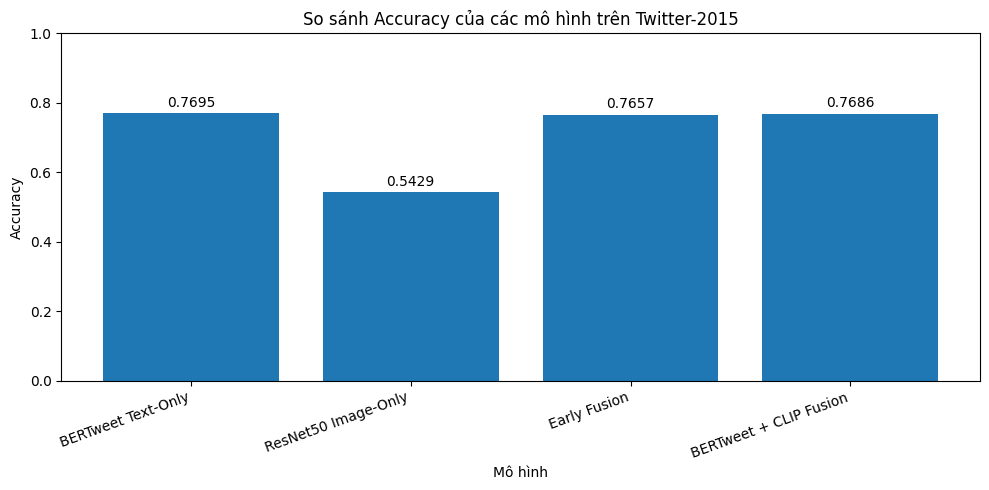

Đã lưu biểu đồ tại: /kaggle/working/twitter2015_outputs/compare_accuracy_no_late_fusion.png


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Tạo bảng kết quả, KHÔNG lấy Late Fusion
compare_results = [
    {
        "model": "BERTweet Text-Only",
        "accuracy": test_metrics_text["accuracy"],
        "f1_macro": test_metrics_text["f1_macro"],
        "f1_weighted": test_metrics_text["f1_weighted"]
    },
    {
        "model": "ResNet50 Image-Only",
        "accuracy": test_metrics_image["accuracy"],
        "f1_macro": test_metrics_image["f1_macro"],
        "f1_weighted": test_metrics_image["f1_weighted"]
    },
    {
        "model": "Early Fusion",
        "accuracy": test_metrics_early["accuracy"],
        "f1_macro": test_metrics_early["f1_macro"],
        "f1_weighted": test_metrics_early["f1_weighted"]
    },
    {
        "model": "BERTweet + CLIP Fusion",
        "accuracy": test_metrics_clip["accuracy"],
        "f1_macro": test_metrics_clip["f1_macro"],
        "f1_weighted": test_metrics_clip["f1_weighted"]
    }
]

compare_df = pd.DataFrame(compare_results)

display(compare_df)

# Vẽ biểu đồ cột Accuracy
plt.figure(figsize=(10, 5))
bars = plt.bar(compare_df["model"], compare_df["accuracy"])

plt.title("So sánh Accuracy của các mô hình trên Twitter-2015")
plt.xlabel("Mô hình")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")

# Hiển thị số trên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

# Lưu ảnh
save_path = OUTPUT_DIR / "compare_accuracy_no_late_fusion.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Đã lưu biểu đồ tại:", save_path)

,model,Accuracy,Precision,Recall,F1-score
0,BERTweet,76.952748,73.031644,74.180450,73.545122
1,ResNet50,54.291225,42.584561,40.468405,40.741614
2,Early Fusion,76.567020,74.428179,68.126629,70.630773
3,BERTweet + CLIP,76.856316,74.230324,68.950230,71.098874


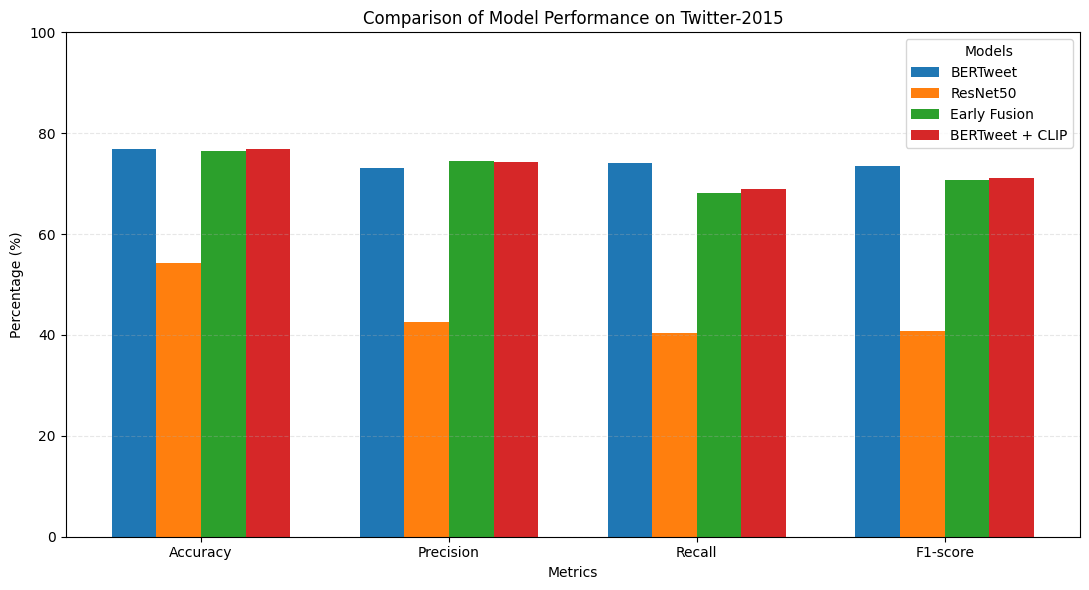

Da luu bieu do tai: /kaggle/working/twitter2015_outputs/grouped_bar_compare_models_no_late.png


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bảng kết quả, không lấy Late Fusion
compare_results = [
    {
        "model": "BERTweet",
        "Accuracy": test_metrics_text["accuracy"] * 100,
        "Precision": test_metrics_text["precision_macro"] * 100,
        "Recall": test_metrics_text["recall_macro"] * 100,
        "F1-score": test_metrics_text["f1_macro"] * 100
    },
    {
        "model": "ResNet50",
        "Accuracy": test_metrics_image["accuracy"] * 100,
        "Precision": test_metrics_image["precision_macro"] * 100,
        "Recall": test_metrics_image["recall_macro"] * 100,
        "F1-score": test_metrics_image["f1_macro"] * 100
    },
    {
        "model": "Early Fusion",
        "Accuracy": test_metrics_early["accuracy"] * 100,
        "Precision": test_metrics_early["precision_macro"] * 100,
        "Recall": test_metrics_early["recall_macro"] * 100,
        "F1-score": test_metrics_early["f1_macro"] * 100
    },
    {
        "model": "BERTweet + CLIP",
        "Accuracy": test_metrics_clip["accuracy"] * 100,
        "Precision": test_metrics_clip["precision_macro"] * 100,
        "Recall": test_metrics_clip["recall_macro"] * 100,
        "F1-score": test_metrics_clip["f1_macro"] * 100
    }
]

compare_df = pd.DataFrame(compare_results)
display(compare_df)

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
models = compare_df["model"].tolist()

x = np.arange(len(metrics))
width = 0.18

plt.figure(figsize=(11, 6))

for i, model in enumerate(models):
    values = compare_df.loc[compare_df["model"] == model, metrics].values.flatten()
    plt.bar(
        x + (i - len(models) / 2) * width + width / 2,
        values,
        width,
        label=model
    )

plt.title("Comparison of Model Performance on Twitter-2015")
plt.xlabel("Metrics")
plt.ylabel("Percentage (%)")
plt.xticks(x, metrics)
plt.ylim(0, 100)
plt.legend(title="Models")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

save_path = OUTPUT_DIR / "grouped_bar_compare_models_no_late.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Da luu bieu do tai:", save_path)